# 02 · The latency/accuracy tradeoff

The headline result. The offline reference is **not a competitor** — it is the infinite-latency asymptote. What is being measured is the cost of a bounded emission delay, and where that cost stops mattering.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join("..", "src")))
os.environ.setdefault("OMP_NUM_THREADS", "2")

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import torch; torch.set_num_threads(2)

TABLES = os.path.join("..", "results", "tables")
def table(name):
    return pd.read_csv(os.path.join(TABLES, name))
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 60)


In [2]:
curve = table('latency_curve.csv')
online = curve[(curve.method == 'online') & np.isfinite(curve.latency_budget_ms)]
online = online.sort_values('latency_budget_ms')
cols = ['latency_budget_ms', 'der', 'der_noise_scale', 'confusion',
        'n_speakers_pred', 'latency_median_ms', 'extra_mean_query_size']
print(online[[c for c in cols if c in online.columns]].to_string(index=False))

 latency_budget_ms      der  der_noise_scale  confusion  n_speakers_pred  latency_median_ms  extra_mean_query_size
               0.0 0.315974         0.055832   0.211112         4.055556                0.0               1.000000
             125.0 0.315974         0.055832   0.211112         4.055556                0.0               1.000000
             250.0 0.305933         0.036832   0.201070         4.125000              250.0               1.962592
             500.0 0.302048         0.026593   0.197185         4.333333              500.0               2.880146
            1000.0 0.301312         0.037910   0.196450         4.555556             1000.0               4.533767
            2000.0 0.304876         0.013412   0.200013         4.791667             2000.0               7.157087
            4000.0 0.319070         0.025263   0.214208         4.916667             4000.0              10.394655
            8000.0 0.315906         0.020328   0.211043         4.819444        

The curve is **flat below one hop** by construction: a budget of `B` ms buys `floor(B / 250)` hops of lookahead, so 0 ms and 125 ms are the same system. Both are in the sweep so that step is visible rather than assumed away.

In [3]:
offline = curve[curve.method.str.startswith('offline')]
cols = ['method', 'der', 'confusion', 'latency_median_ms']
print(offline[cols].to_string(index=False))

          method      der  confusion  latency_median_ms
     offline_ahc 0.330252   0.225389       29633.680556
offline_spectral 0.273753   0.168891       29633.680556


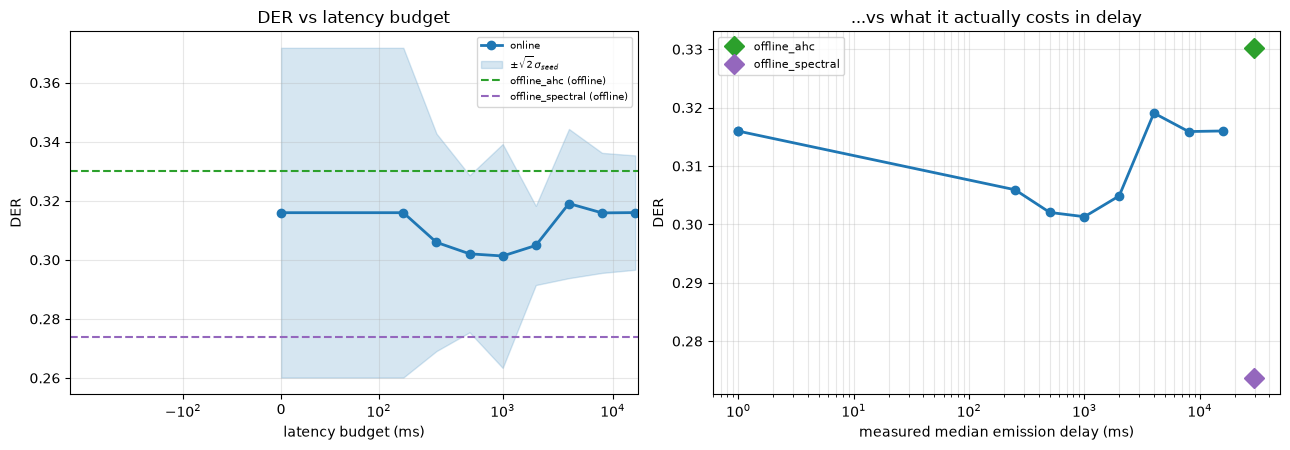

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
x = online.latency_budget_ms.to_numpy(float); y = online.der.to_numpy(float)
b = np.nan_to_num(online.der_noise_scale.to_numpy(float))
axes[0].plot(x, y, 'o-', lw=2, color='#1f77b4', label='online')
axes[0].fill_between(x, y - b, y + b, alpha=0.18, color='#1f77b4',
                     label=r'$\pm\sqrt{2}\sigma_{seed}$')
for _, r in offline.iterrows():
    axes[0].axhline(r.der, ls='--', lw=1.5,
                    color='#2ca02c' if 'ahc' in r.method else '#9467bd',
                    label=f"{r.method} (offline)")
axes[0].set_xscale('symlog', linthresh=125)
axes[0].set_xlabel('latency budget (ms)'); axes[0].set_ylabel('DER')
axes[0].set_title('DER vs latency budget'); axes[0].grid(alpha=0.3)
axes[0].legend(fontsize=7.5)
axes[1].plot(np.maximum(online.latency_median_ms, 1),
         y, 'o-', lw=2, color='#1f77b4')
for _, r in offline.iterrows():
    axes[1].plot(r.latency_median_ms, r.der, 'D', ms=10,
                 color='#2ca02c' if 'ahc' in r.method else '#9467bd',
                 label=r.method)
axes[1].set_xscale('log'); axes[1].set_xlabel('measured median emission delay (ms)')
axes[1].set_ylabel('DER')
axes[1].set_title('...vs what it actually costs in delay')
axes[1].grid(alpha=0.3, which='both'); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## Where is the gap, and is it real?

Every difference is placed against `sqrt(2) * seed_sd` — the run-to-run scale of a difference between two runs. Anything smaller is noise regardless of its p-value.

In [5]:
summary = table('method_summary.csv')
cols = ['variant', 'der', 'der_seed_sd', 'der_noise_scale', 'miss',
        'false_alarm', 'confusion', 'jer', 'latency_median_ms', 'n_speakers_pred']
print(summary[[c for c in cols if c in summary.columns]].to_string(index=False))

                 variant      der  der_seed_sd  der_noise_scale     miss  false_alarm  confusion      jer  latency_median_ms  n_speakers_pred
                  online 0.302048     0.018804         0.026593 0.080935     0.023928   0.197185 0.510175         500.000000         4.333333
            naive_online 0.291551     0.028995         0.041005 0.080935     0.023928   0.186688 0.495458           0.000000         3.958333
             offline_ahc 0.330252     0.030222         0.042741 0.080935     0.023928   0.225389 0.583663       29633.680556         3.138889
        offline_spectral 0.273753     0.019996         0.028278 0.080935     0.023928   0.168891 0.499892       29633.680556         3.222222
     online_oracle_count 0.303767     0.024792         0.035061 0.080935     0.023928   0.198904 0.559365         500.000000         3.416667
offline_ahc_oracle_count 0.332990     0.033425         0.047269 0.080935     0.023928   0.228127 0.614505       29633.680556         2.916667
      

In [6]:
tests = table('statistical_tests.csv')
sub = tests[tests.metric == 'der']
print(sub[['name_b', 'mean_a', 'mean_b', 'delta', 'ci_lower', 'ci_upper',
           'p_value', 'p_adjusted', 'noise_scale', 'noise_ratio',
           'verdict']].to_string(index=False))

                  name_b   mean_a   mean_b     delta  ci_lower  ci_upper  p_value  p_adjusted  noise_scale  noise_ratio         verdict
            naive_online 0.308997 0.268942  0.040056  0.004586  0.081998 0.229190    0.916759     0.041005     0.976858    inside noise
             offline_ahc 0.308997 0.343524 -0.034527 -0.060706 -0.008718 0.042489    0.084978     0.042741     0.807820    inside noise
        offline_spectral 0.308997 0.250665  0.058332  0.013009  0.107626 0.101096    0.404386     0.028278     2.062809 not significant
     online_oracle_count 0.308997 0.303310  0.005688 -0.012577  0.027026 0.622070    1.000000     0.035061     0.162220    inside noise
offline_ahc_oracle_count 0.308997 0.338806 -0.029809 -0.057582 -0.000407 0.069102    0.138203     0.047269     0.630619    inside noise
       online_oracle_vad 0.308997 0.305032  0.003966 -0.002775  0.008809 0.002246    0.011229     0.040780     0.097244    inside noise
  offline_ahc_oracle_vad 0.308997 0.318694 -0.00

**Unit of analysis.** These paired tests are over the 24 test recordings of one seed, so they condition on *one trained model per method*. They say whether these two sets of weights differ on this test set — not whether the method is better. That is why the `noise_ratio` column, not `p_adjusted`, decides the verdict.